In [6]:
import os
print(os.listdir("/content"))

['.config', 'disease_gene_reference_FINAL_week1.csv', 'brainspan_gene_peak_windows.csv', 'dummy_delayed_gene_list.csv', 'sample_data']


In [7]:
import pandas as pd


disease_ref = pd.read_csv("/content/disease_gene_reference_FINAL_week1.csv")
dummy_query = pd.read_csv("/content/dummy_delayed_gene_list.csv")

disease_genes = set(disease_ref["ensembl_id"].dropna())
query_genes = set(dummy_query["ensembl_id"].dropna())

overlap = disease_genes & query_genes

print(f"Disease reference genes: {len(disease_genes)}")
print(f"Dummy query genes: {len(query_genes)}")
print(f"Overlap: {len(overlap)}")

Disease reference genes: 2078
Dummy query genes: 90
Overlap: 17


In [8]:
import pandas as pd
import numpy as np
from scipy.stats import hypergeom

np.random.seed(42)


disease_ref = pd.read_csv("/content/disease_gene_reference_FINAL_week1.csv")
dummy_query = pd.read_csv("/content/dummy_delayed_gene_list.csv")
brainspan_peaks = pd.read_csv("/content/brainspan_gene_peak_windows.csv")

BACKGROUND = set(brainspan_peaks["ensembl_gene_id"].dropna())

disease_genes = set(disease_ref["ensembl_id"].dropna()) & BACKGROUND
query_genes = set(dummy_query["ensembl_id"].dropna()) & BACKGROUND
overlap = disease_genes & query_genes

N = len(BACKGROUND)
K = len(disease_genes)
n = len(query_genes)
k = len(overlap)


hypergeom_p = hypergeom.sf(k - 1, N, K, n)

rng = np.random.default_rng(42)
bg_array = np.array(list(BACKGROUND))
null_overlaps = np.empty(10000, dtype=int)
for i in range(10000):
    draw = rng.choice(bg_array, size=n, replace=False)
    null_overlaps[i] = len(set(draw) & disease_genes)
permutation_p = (np.sum(null_overlaps >= k) + 1) / (10000 + 1)

print(f"Background size: {N}")
print(f"Disease genes in background: {K}")
print(f"Query size: {n}")
print(f"Observed overlap: {k}")
print(f"Hypergeometric p-value: {hypergeom_p:.4f}")
print(f"Permutation p-value: {permutation_p:.4f}")

Background size: 52376
Disease genes in background: 2058
Query size: 90
Observed overlap: 17
Hypergeometric p-value: 0.0000
Permutation p-value: 0.0001


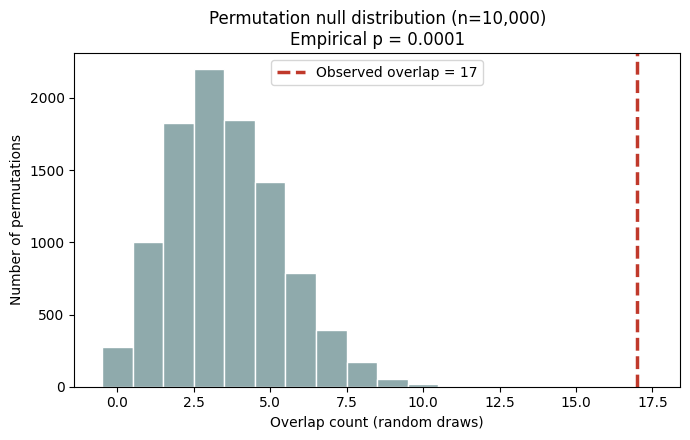

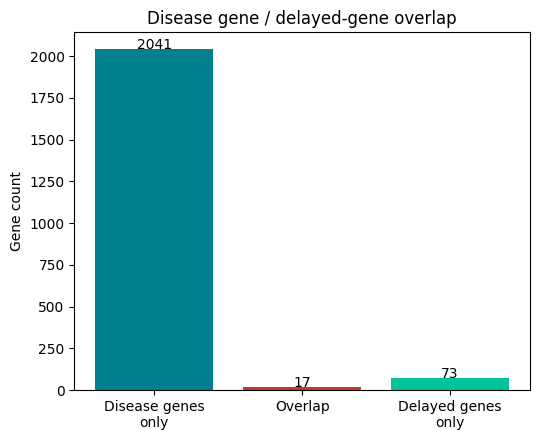

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(null_overlaps, bins=range(0, max(null_overlaps.max(), k) + 2),
        color="#8FAAAC", edgecolor="white", align="left")
ax.axvline(k, color="#C0392B", linewidth=2.5, linestyle="--",
           label=f"Observed overlap = {k}")
ax.set_xlabel("Overlap count (random draws)")
ax.set_ylabel("Number of permutations")
ax.set_title(f"Permutation null distribution (n=10,000)\nEmpirical p = {permutation_p:.4f}")
ax.legend()
plt.tight_layout()
plt.show()


disease_only = len(disease_genes) - k
query_only = n - k
fig, ax = plt.subplots(figsize=(5.5, 4.5))
bars = ax.bar(
    ["Disease genes\nonly", "Overlap", "Delayed genes\nonly"],
    [disease_only, k, query_only],
    color=["#028090", "#C0392B", "#02C39A"]
)
ax.set_ylabel("Gene count")
ax.set_title("Disease gene / delayed-gene overlap")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2, str(int(b.get_height())), ha="center")
plt.tight_layout()
plt.show()

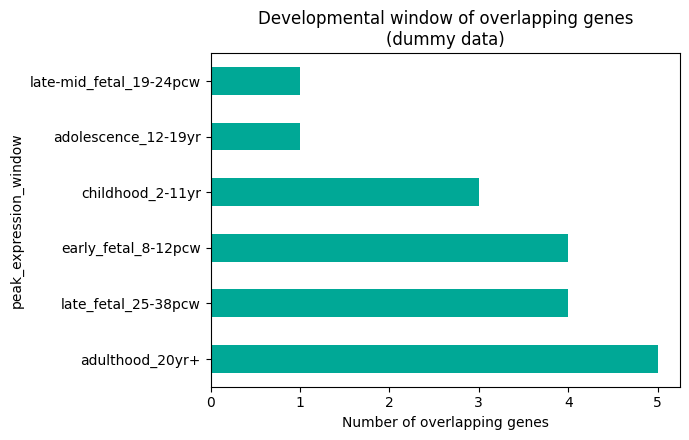

peak_expression_window
adulthood_20yr+            5
late_fetal_25-38pcw        4
early_fetal_8-12pcw        4
childhood_2-11yr           3
adolescence_12-19yr        1
late-mid_fetal_19-24pcw    1
Name: count, dtype: int64


In [10]:

overlap_detail = disease_ref[disease_ref["ensembl_id"].isin(overlap)]
overlap_windows = overlap_detail["peak_expression_window"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4.5))
if len(overlap_windows) > 0:
    overlap_windows.plot(kind="barh", ax=ax, color="#00A896")
else:
    ax.text(0.5, 0.5, "No overlapping genes in this run",
            ha="center", va="center", transform=ax.transAxes)
ax.set_xlabel("Number of overlapping genes")
ax.set_title("Developmental window of overlapping genes\n(dummy data)")
plt.tight_layout()
plt.show()

print(overlap_windows)